# EM-DAT - The international disaster database

The goal is to do some basic data preprocessing and getting insights about the EM-DAT database, for a better understanding of visualizations options 

**Sections:** 
1. Imports and Setup
2. Data Inspection
3. Data Cleaning
4. Disaster Analysis
5. Time Analysis
6. Geographical Analysis
7. Impact Analysis
8. Fun Plots

# Imports and setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import plotly.express as px 

In [5]:
warnings.filterwarnings('ignore')
pd.set_option('display.precision', 3)
sns.set_theme(style='darkgrid')

# Data Inspection

In [30]:
FILE_PATH = os.path.expanduser('~/Desktop/MA1/Data Visualization/emdat_data.xlsx')

df_raw = pd.read_excel(FILE_PATH, sheet_name="EM-DAT Data")
df_info = pd.read_excel(FILE_PATH, sheet_name="EM-DAT Info")

print(f'Shape: {df_raw.shape}')
df_raw.info()

Shape: (17756, 47)
<class 'pandas.DataFrame'>
RangeIndex: 17756 entries, 0 to 17755
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     17756 non-null  str    
 1   Historic                                   17756 non-null  str    
 2   Classification Key                         17756 non-null  str    
 3   Disaster Group                             17756 non-null  str    
 4   Disaster Subgroup                          17756 non-null  str    
 5   Disaster Type                              17756 non-null  str    
 6   Disaster Subtype                           17756 non-null  str    
 7   External IDs                               4594 non-null   str    
 8   Event Name                                 4319 non-null   str    
 9   ISO                                        17756 non-null  str    
 10  Country       

In [7]:
df_raw.head(3)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,30000.0,1.131e+06,2.652,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652,NaN,NaN,2003-07-01,2023-09-25


### Supplementary information about source

In [8]:
df_info

,Source:,"EM-DAT, CRED / UCLouvain, Brussels, Belgium"
0,NaN,https://www.emdat.be
1,Glossary:,https://doc.emdat.be/docs/data-structure-and-c...
2,Version:,2026-03-13
3,File creation:,"Sat, 14 Mar 2026 15:52:56 UTC"
4,Table type:,public_emdat_custom_request
5,# of records:,17756


### Columns completness

In [32]:
missing = (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
missing[missing > 0].sort_values(ascending=False)

Reconstruction Costs ('000 US$)              99.8
Reconstruction Costs, Adjusted ('000 US$)    99.8
AID Contribution ('000 US$)                  95.6
Insured Damage, Adjusted ('000 US$)          93.6
Insured Damage ('000 US$)                    93.5
River Basin                                  91.0
No. Homeless                                 85.7
Latitude                                     84.0
Longitude                                    84.0
Associated Types                             76.0
Event Name                                   75.7
External IDs                                 74.1
No. Injured                                  73.8
Origin                                       73.4
Magnitude                                    70.2
Total Damage, Adjusted ('000 US$)            68.3
Total Damage ('000 US$)                      67.8
GADM Admin Units                             56.0
Admin Units                                  52.8
No. Affected                                 40.3


It's interesting to notice that some attributs will be difficult to use given the lack of information: like reconstruction cost or nr of homeless. Where as the dataset seems very complet for the country, subregion, region, disaster type, year ...

# Data Cleaning

Make the dataset start from a more limited time span could be interesting (like 1950s?), with the eda we could also notice that the data doesn't seem very complet from 2023 and up 

In [10]:
df = df_raw.copy()
#df = df[df['Start Year'] >= 1950].copy()

df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace(".", "").str.replace("/", "_")
df.columns.tolist()

['disno',
 'historic',
 'classification_key',
 'disaster_group',
 'disaster_subgroup',
 'disaster_type',
 'disaster_subtype',
 'external_ids',
 'event_name',
 'iso',
 'country',
 'subregion',
 'region',
 'location',
 'origin',
 'associated_types',
 'ofda_bha_response',
 'appeal',
 'declaration',
 "aid_contribution_('000_us$)",
 'magnitude',
 'magnitude_scale',
 'latitude',
 'longitude',
 'river_basin',
 'start_year',
 'start_month',
 'start_day',
 'end_year',
 'end_month',
 'end_day',
 'total_deaths',
 'no_injured',
 'no_affected',
 'no_homeless',
 'total_affected',
 "reconstruction_costs_('000_us$)",
 "reconstruction_costs,_adjusted_('000_us$)",
 "insured_damage_('000_us$)",
 "insured_damage,_adjusted_('000_us$)",
 "total_damage_('000_us$)",
 "total_damage,_adjusted_('000_us$)",
 'cpi',
 'admin_units',
 'gadm_admin_units',
 'entry_date',
 'last_update']

Rename interesting columns to make them easier to use for plotting, and convert to adapted format. Creating a column for decades can be interesting to group, and converting damage to a more readable format.

In [11]:
df = df.rename(columns={
    'start_year':                        'year',
    'start_month':                       'month',
    'total_deaths':                      'deaths',
    'no_injured':                        'injured',
    'no_homeless':                       'homeless',
    "total_damage_('000_us$)":           'damage_000usd',
    "total_damage,_adjusted_('000_us$)": 'damage_adj_000usd',
})

df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'
df['damage_bn_usd'] = df['damage_000usd'] / 1_000_000

df.head(3)

,disno,historic,classification_key,disaster_group,disaster_subgroup,disaster_type,disaster_subtype,external_ids,event_name,iso,...,"insured_damage,_adjusted_('000_us$)",damage_000usd,damage_adj_000usd,cpi,admin_units,gadm_admin_units,entry_date,last_update,decade,damage_bn_usd
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,30000.0,1.131e+06,2.652,NaN,NaN,2004-10-18,2023-10-17,1900s,0.03
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,2.652,NaN,NaN,2003-07-01,2023-09-25,1900s,NaN
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,2.652,NaN,NaN,2003-07-01,2023-09-25,1900s,NaN


Get a better understanding of the number of different values for categories

In [12]:
print(f'   Years:          {int(df.year.min())} to {int(df.year.max())}')
print(f'   Countries:      {df.country.nunique()}')
print(f'   Disaster group: {df.disaster_group.nunique()}')
print(f'   Disaster subgroup: {df.disaster_subgroup.nunique()}')
print(f'   Disaster types: {df.disaster_type.nunique()}')

   Years:          1900 to 2026
   Countries:      230
   Disaster group: 1
   Disaster subgroup: 6
   Disaster types: 15


# Disaster analysis

We can notice from before that in this dataset we only have disasters from Natural cause, we could now analyze the corresponding subgroups and types. We can observe that for the subgroups hydrological and meteorological dominates where as for the types floods and storms are the most present.

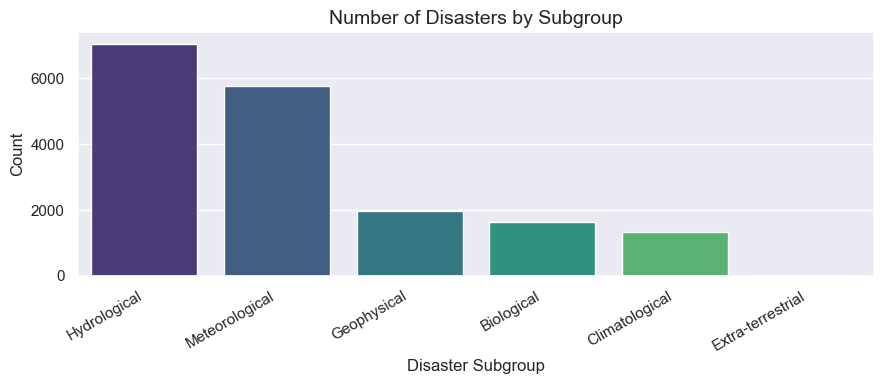

disaster_subgroup  count
     Hydrological   7047
   Meteorological   5783
      Geophysical   1978
       Biological   1622
   Climatological   1325
Extra-terrestrial      1


In [13]:
subgroup_counts = df['disaster_subgroup'].value_counts().reset_index()
subgroup_counts.columns = ['disaster_subgroup', 'count']

plt.figure(figsize=(9, 4))
sns.barplot(data=subgroup_counts, x='disaster_subgroup', y='count', palette='viridis')
plt.title('Number of Disasters by Subgroup', fontsize=14)
plt.xlabel('Disaster Subgroup')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(subgroup_counts.to_string(index=False))

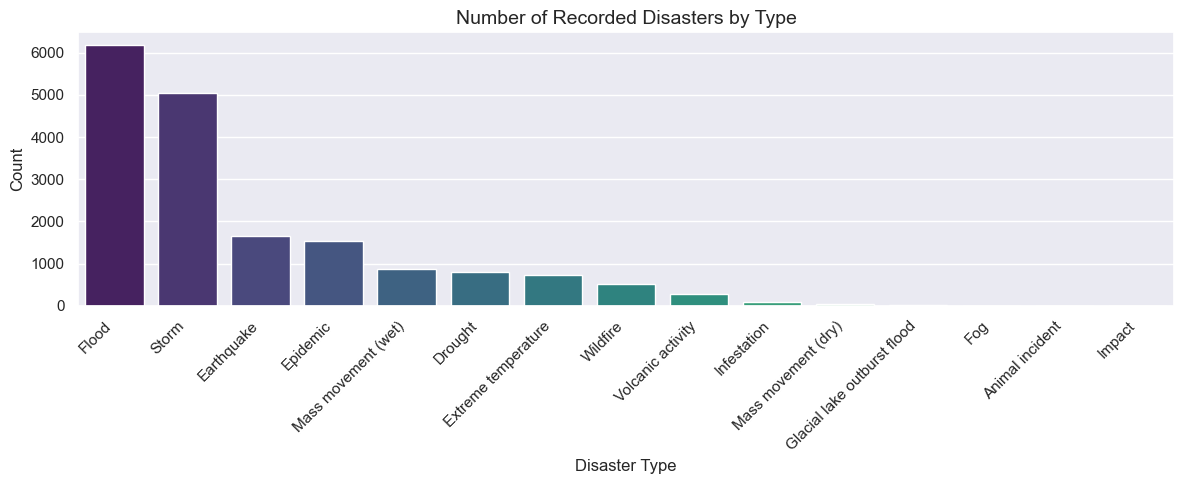

              disaster_type  count
                      Flood   6175
                      Storm   5053
                 Earthquake   1650
                   Epidemic   1526
        Mass movement (wet)    872
                    Drought    803
        Extreme temperature    729
                   Wildfire    514
          Volcanic activity    282
                Infestation     95
        Mass movement (dry)     46
Glacial lake outburst flood      8
                        Fog      1
            Animal incident      1
                     Impact      1


In [14]:
type_counts = df['disaster_type'].value_counts().reset_index()
type_counts.columns = ['disaster_type', 'count']

plt.figure(figsize=(12, 5))
sns.barplot(data=type_counts, x='disaster_type', y='count', palette='viridis')
plt.title('Number of Recorded Disasters by Type', fontsize=14)
plt.xlabel('Disaster Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(type_counts.to_string(index=False))

# Time Analyis

Data before 1950 is sparse and likely underreported it makes sense to focus on 1950 onward for temporal trends?

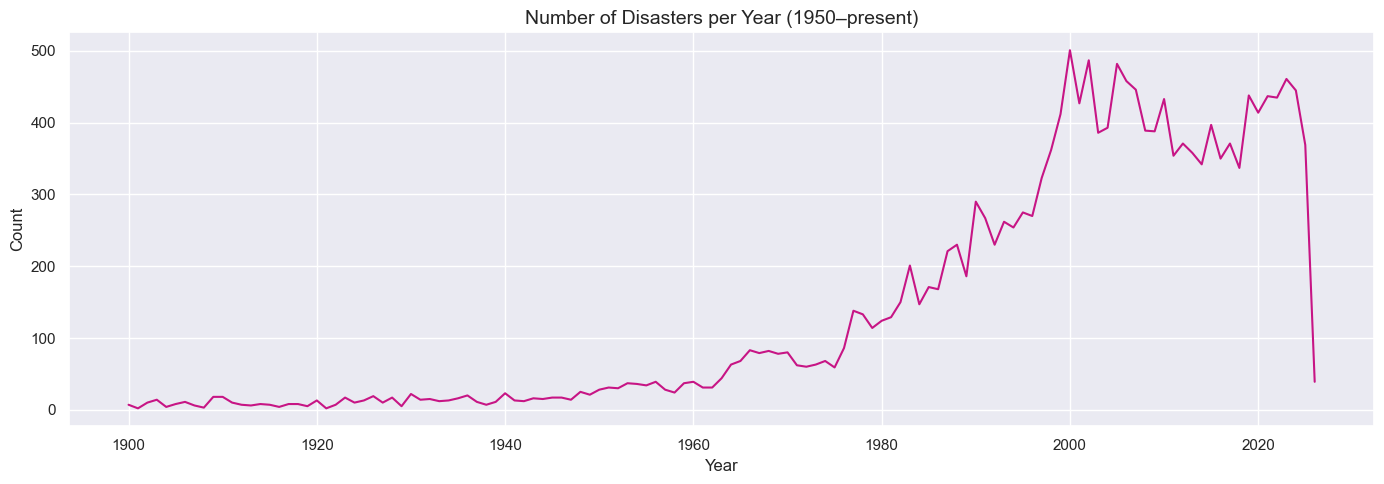

In [15]:


yearly = df.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(14, 5))
sns.lineplot(data=yearly, x='year', y='count', color='mediumvioletred')
plt.title('Number of Disasters per Year (1950–present)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

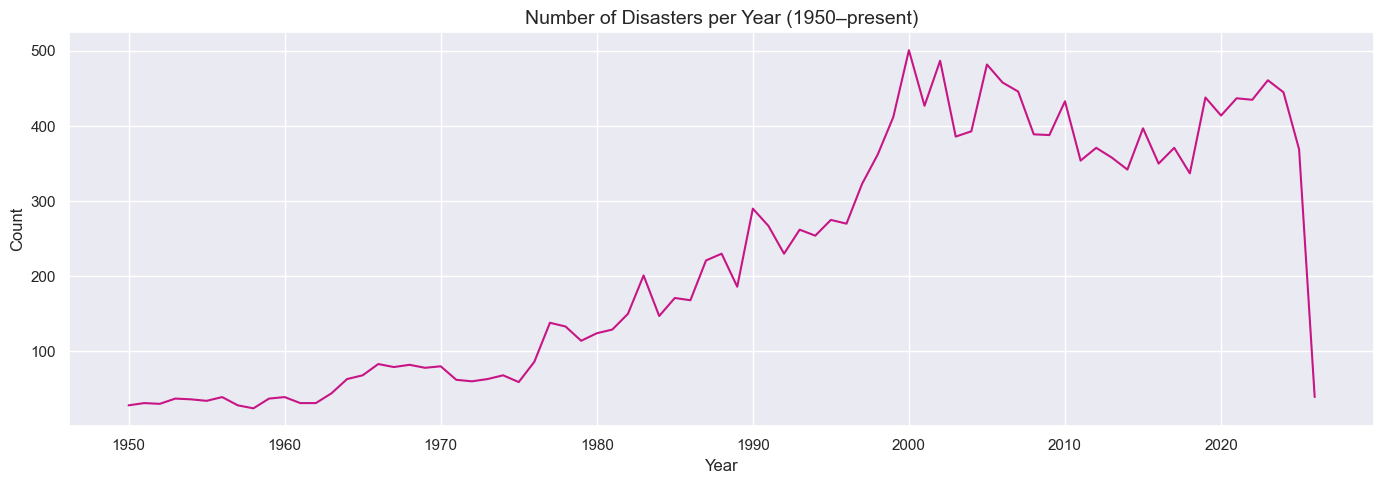

In [16]:
df_time = df[df['year'] >= 1950].copy()

yearly = df_time.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(14, 5))
sns.lineplot(data=yearly, x='year', y='count', color='mediumvioletred')
plt.title('Number of Disasters per Year (1950–present)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Breaking by type over decade, top 5 to keep it more readable

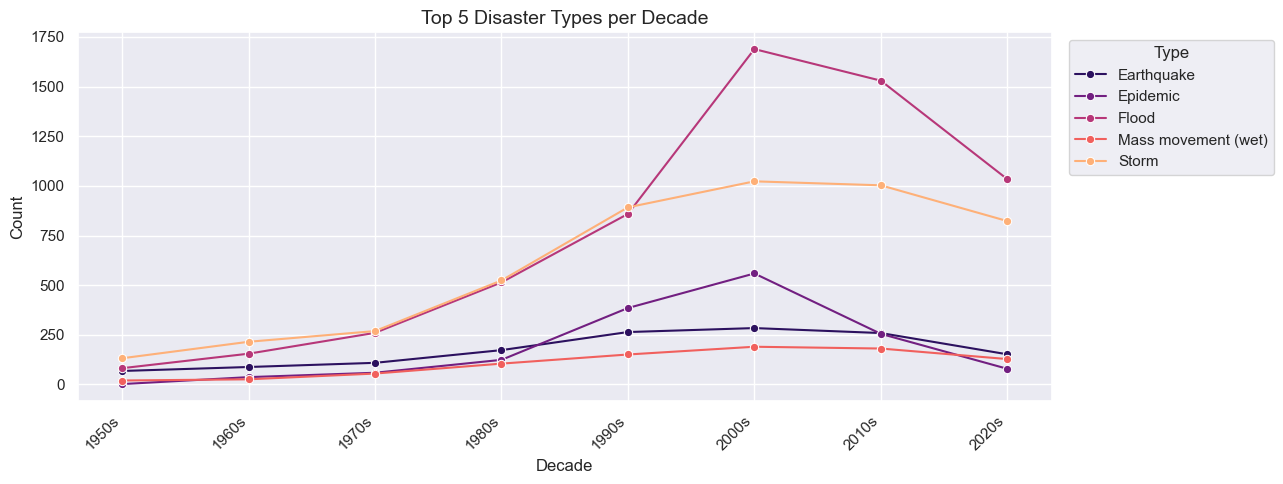

In [17]:
top_types = df_time['disaster_type'].value_counts().head(5).index.tolist()
decade_type = df_time[df_time['disaster_type'].isin(top_types)].groupby(['decade', 'disaster_type']).size().reset_index(name='count')

plt.figure(figsize=(13, 5))
sns.lineplot(data=decade_type, x='decade', y='count', hue='disaster_type', palette='magma', marker='o')
plt.title('Top 5 Disaster Types per Decade', fontsize=14)
plt.xlabel('Decade')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Geographical Analysis 

We could ask ourselves if Asia and Americas dominate in this datasets because they are the most concerned regions or the most represented ?

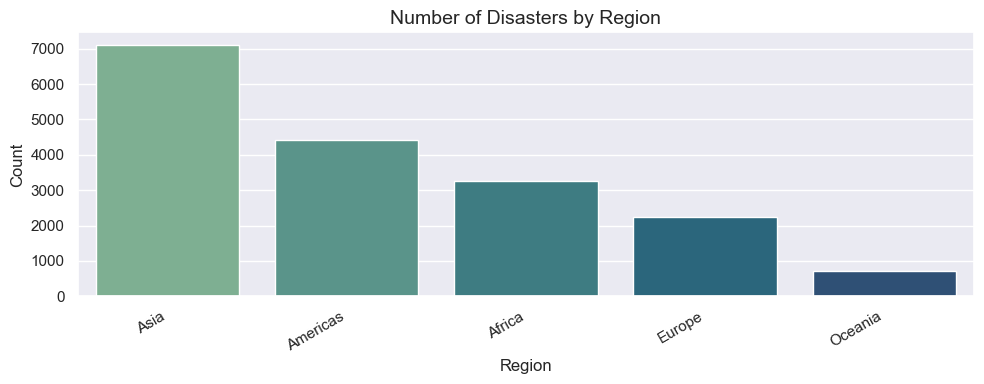

  region  count
    Asia   7105
Americas   4430
  Africa   3272
  Europe   2228
 Oceania    721


In [18]:
region_counts = df.groupby('region').size().reset_index(name='count').sort_values('count', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=region_counts, x='region', y='count', palette='crest')
plt.title('Number of Disasters by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(region_counts.to_string(index=False))

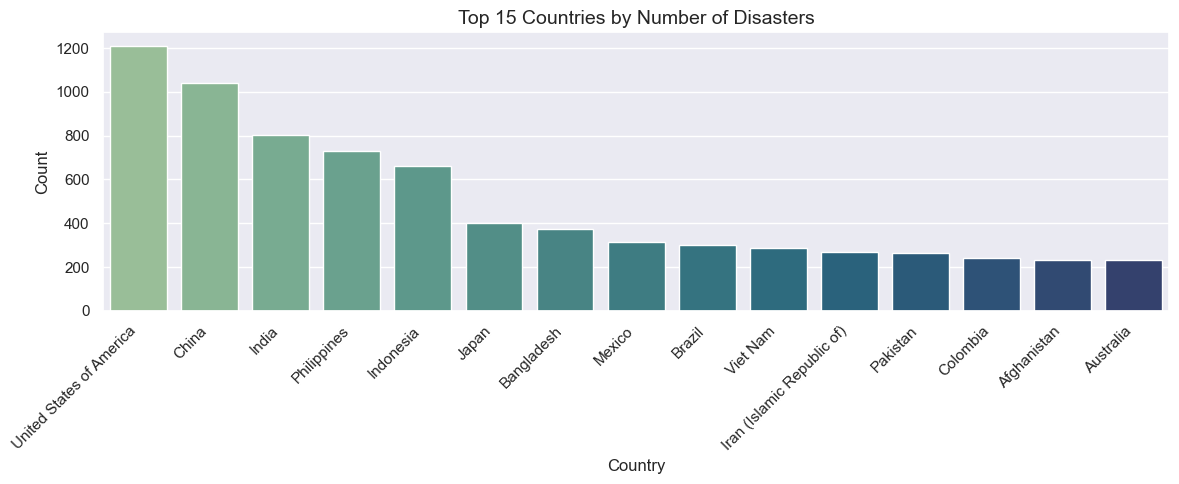

                   country  count
  United States of America   1211
                     China   1039
                     India    804
               Philippines    730
                 Indonesia    660
                     Japan    403
                Bangladesh    372
                    Mexico    313
                    Brazil    301
                  Viet Nam    288
Iran (Islamic Republic of)    270
                  Pakistan    262
                  Colombia    243
               Afghanistan    231
                 Australia    230


In [19]:
top_countries = df['country'].value_counts().head(15).reset_index()
top_countries.columns = ['country', 'count']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_countries, x='country', y='count', palette='crest')
plt.title('Top 15 Countries by Number of Disasters', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(top_countries.to_string(index=False))

# Impact Analysis

Top 20 deadliest events in the dataset, to see what the outliers are.

In [20]:
top20 = df[['year', 'country', 'disaster_type', 'event_name', 'deaths']]\
          .sort_values('deaths', ascending=False)\
          .head(20)\
          .reset_index(drop=True)

top20.index += 1
top20.columns = ['Year', 'Country', 'Type', 'Event Name', 'Deaths']
top20['Deaths'] = top20['Deaths'].apply(lambda x: f'{int(x):,}' if pd.notna(x) else '-')

display(top20)

,Year,Country,Type,Event Name,Deaths
1,1931,China,Flood,NaN,"3,700,000"
2,1928,China,Drought,NaN,"3,000,000"
3,1917,Soviet Union,Epidemic,NaN,"2,500,000"
4,1959,China,Flood,NaN,"2,000,000"
5,1920,India,Epidemic,Bubonic,"2,000,000"
6,1943,Bangladesh,Drought,NaN,"1,900,000"
7,1909,China,Epidemic,Bubonic,"1,500,000"
8,1942,India,Drought,NaN,"1,500,000"
9,1965,India,Drought,NaN,"1,500,000"
10,1907,India,Epidemic,Bubonic,"1,300,000"


We can see that we have very high values for the outliers so maybe it would be better to look at the deaths with the median rather then the mean to have a more representative visualization.

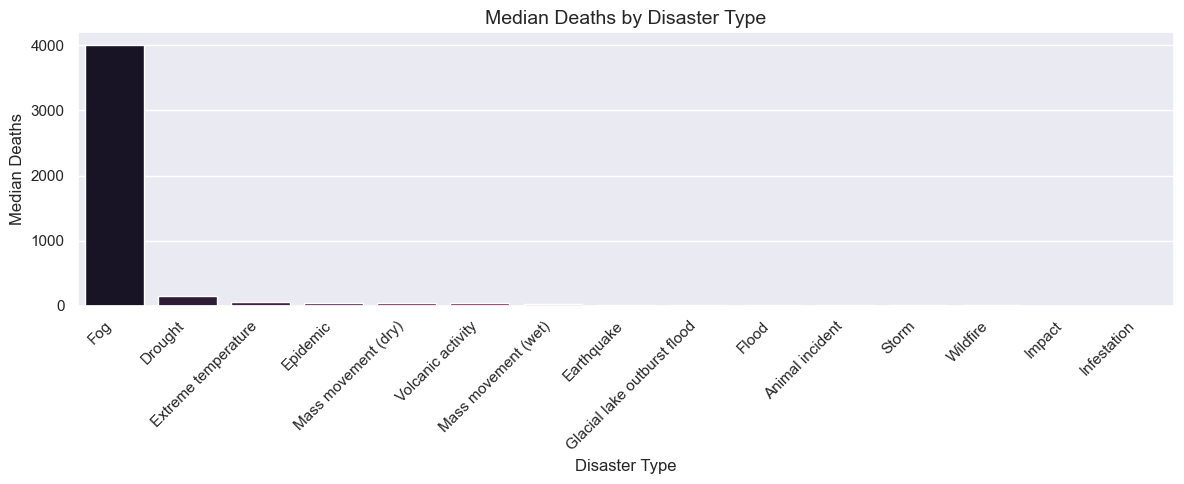

              disaster_type  median_deaths
                        Fog         4000.0
                    Drought          143.0
        Extreme temperature           50.0
                   Epidemic           44.0
        Mass movement (dry)           38.0
          Volcanic activity           37.0
        Mass movement (wet)           26.0
                 Earthquake           18.0
Glacial lake outburst flood           18.0
                      Flood           16.0
            Animal incident           12.0
                      Storm           12.0
                   Wildfire            5.0
                     Impact            NaN
                Infestation            NaN


In [21]:
deaths_by_type = df.groupby('disaster_type')['deaths'].median().reset_index()
deaths_by_type.columns = ['disaster_type', 'median_deaths']
deaths_by_type = deaths_by_type.sort_values('median_deaths', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=deaths_by_type, x='disaster_type', y='median_deaths', palette='rocket')
plt.title('Median Deaths by Disaster Type', fontsize=14)
plt.xlabel('Disaster Type')
plt.ylabel('Median Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(deaths_by_type.to_string(index=False))

We have to be careful about outliers and our choices for median and mean. We can see on the previous graph that since fog only arrived very rarely it's not representative. Let's try a graph with at least 20 recorded events:

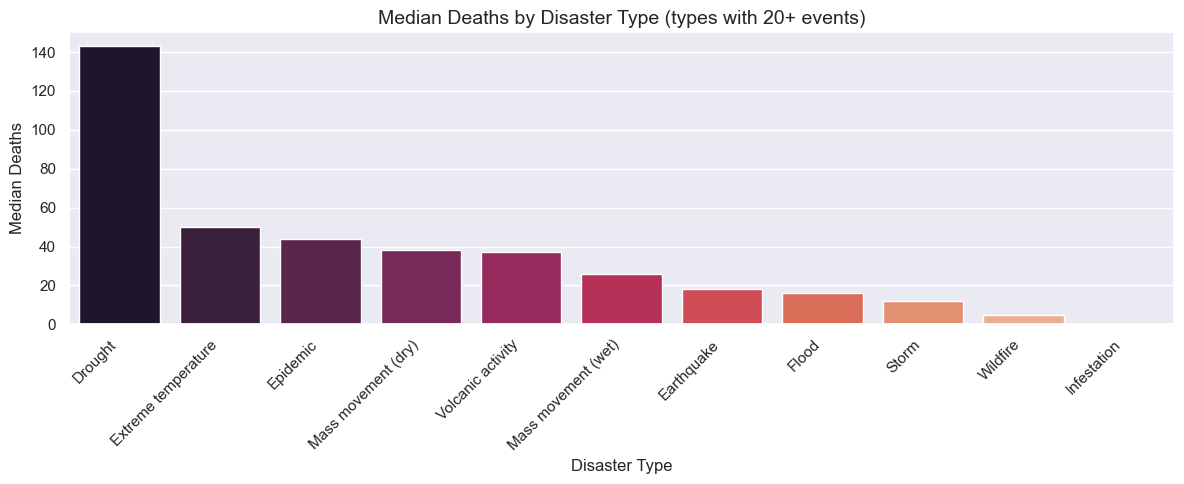

      disaster_type  median_deaths
            Drought          143.0
Extreme temperature           50.0
           Epidemic           44.0
Mass movement (dry)           38.0
  Volcanic activity           37.0
Mass movement (wet)           26.0
         Earthquake           18.0
              Flood           16.0
              Storm           12.0
           Wildfire            5.0
        Infestation            NaN


In [22]:
type_counts_filter = df['disaster_type'].value_counts()
valid_types = type_counts_filter[type_counts_filter >= 20].index

deaths_by_type = df[df['disaster_type'].isin(valid_types)].groupby('disaster_type')['deaths'].median().reset_index()
deaths_by_type.columns = ['disaster_type', 'median_deaths']
deaths_by_type = deaths_by_type.sort_values('median_deaths', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=deaths_by_type, x='disaster_type', y='median_deaths', palette='rocket')
plt.title('Median Deaths by Disaster Type (types with 20+ events)', fontsize=14)
plt.xlabel('Disaster Type')
plt.ylabel('Median Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(deaths_by_type.to_string(index=False))

Economic damage is very incomplete with about 68% missing, so take regional totals here as a lower bound rather than absolute truth.

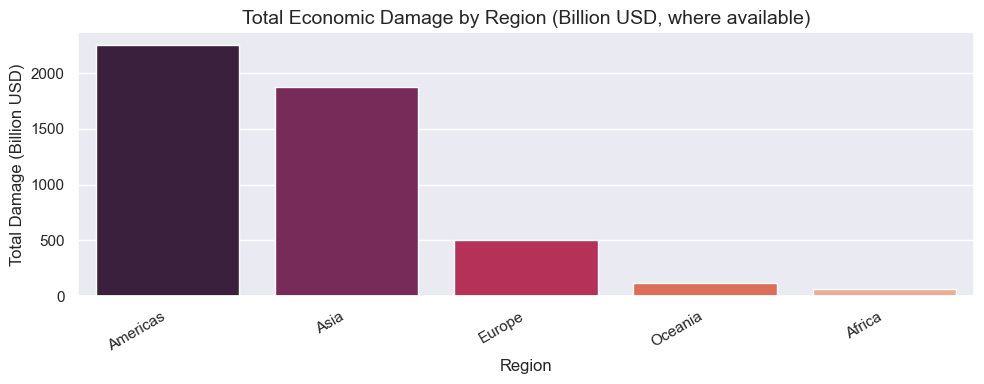

  region  total_damage_bn
Americas         2251.941
    Asia         1876.575
  Europe          508.123
 Oceania          122.241
  Africa           67.494


In [23]:
damage_region = df.groupby('region')['damage_bn_usd'].sum().reset_index()
damage_region.columns = ['region', 'total_damage_bn']
damage_region = damage_region.sort_values('total_damage_bn', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=damage_region, x='region', y='total_damage_bn', palette='rocket')
plt.title('Total Economic Damage by Region (Billion USD, where available)', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Damage (Billion USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(damage_region.to_string(index=False))

# Fun Plots

### Plots from 1950 and up

In [25]:
df = df[df['year'] >= 1950].copy()

To get a better understanding of the damage of different events we can look at the human causalities but also economical ones (careful though since the second has quite a lot of missing data) 

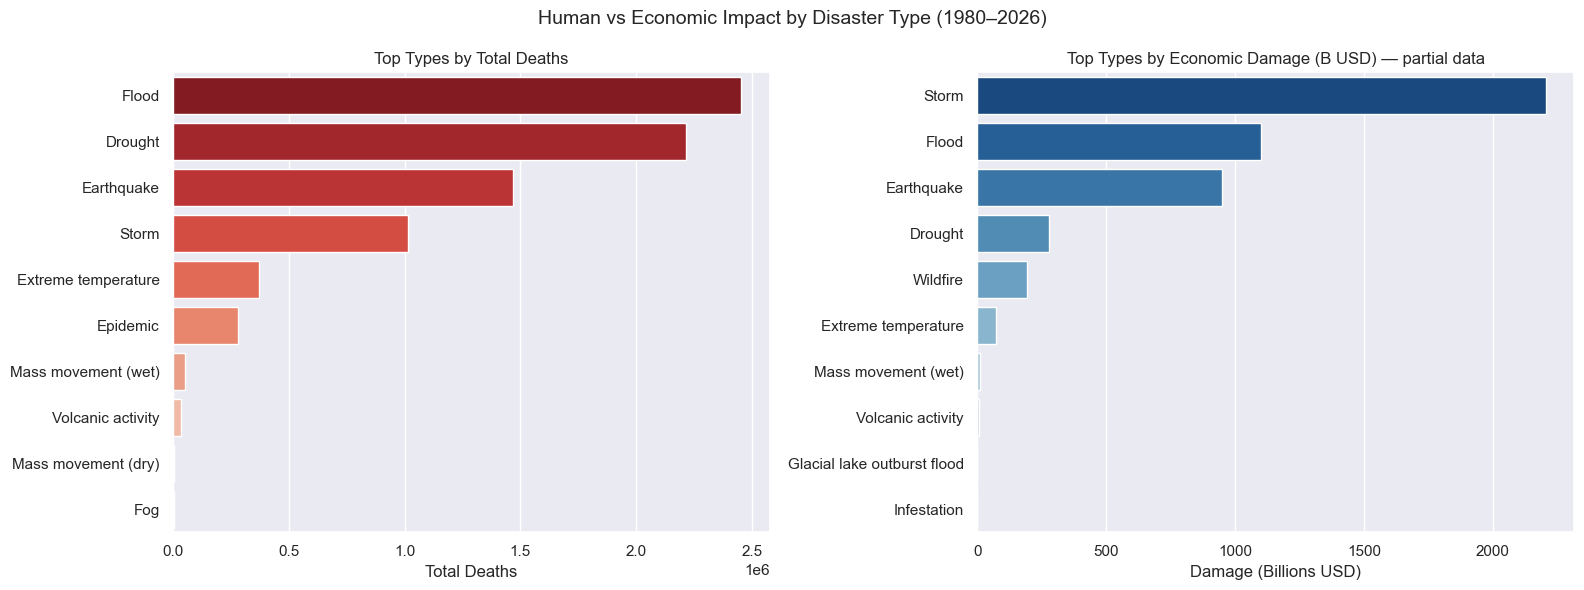

Average deaths per event by type:
              disaster_type  avg_deaths_per_event  event_count
                        Fog                4000.0            1
                    Drought                2872.1          771
                 Earthquake                1051.6         1397
        Extreme temperature                 511.1          727
                      Flood                 400.8         6123
                      Storm                 207.5         4881
                   Epidemic                 188.6         1500
          Volcanic activity                 136.9          260
        Mass movement (dry)                 103.2           42
        Mass movement (wet)                  61.6          856
Glacial lake outburst flood                  59.8            8
            Animal incident                  12.0            1
                   Wildfire                   7.4          505
                     Impact                   0.0            1
                Infes

In [27]:
impact = df.groupby('disaster_type').agg(
    total_deaths=('deaths', 'sum'),
    total_damage=('damage_bn_usd', 'sum'),
    event_count=('year', 'count')
).reset_index()
impact['avg_deaths_per_event'] = (impact['total_deaths'] / impact['event_count']).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_deaths = impact.sort_values('total_deaths', ascending=False).head(10)
sns.barplot(data=top_deaths, x='total_deaths', y='disaster_type', palette='Reds_r', ax=axes[0])
axes[0].set_title('Top Types by Total Deaths')
axes[0].set_xlabel('Total Deaths')
axes[0].set_ylabel('')

top_damage = impact.sort_values('total_damage', ascending=False).head(10)
sns.barplot(data=top_damage, x='total_damage', y='disaster_type', palette='Blues_r', ax=axes[1])
axes[1].set_title('Top Types by Economic Damage (B USD) — partial data')
axes[1].set_xlabel('Damage (Billions USD)')
axes[1].set_ylabel('')

plt.suptitle('Human vs Economic Impact by Disaster Type (1980–2026)', fontsize=14)
plt.tight_layout()
plt.show()

print('Average deaths per event by type:')
print(impact[['disaster_type','avg_deaths_per_event','event_count']].sort_values('avg_deaths_per_event', ascending=False).to_string(index=False))

Same we have in our dataset the total of people affected by the event, even if it doesn't end in casualty this is interesting data to have (note that it misses 25% of data, for 1900 - 2026) 

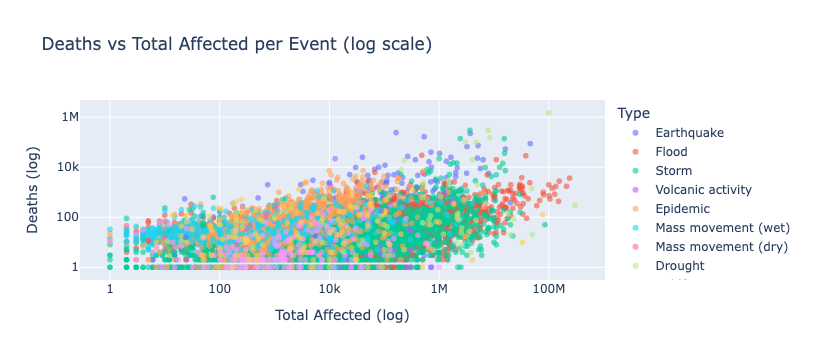

In [35]:
scatter_df = df[['disaster_type', 'deaths', 'total_affected', 'country', 'year']].dropna()
scatter_df = scatter_df[(scatter_df['deaths'] > 0) & (scatter_df['total_affected'] > 0)]

fig = px.scatter(
    scatter_df, x='total_affected', y='deaths', color='disaster_type',
    hover_data=['country', 'year'], log_x=True, log_y=True,
    title='Deaths vs Total Affected per Event (log scale)',
    labels={'total_affected': 'Total Affected (log)', 'deaths': 'Deaths (log)', 'disaster_type': 'Type'},
    opacity=0.6
)
fig.show()

The log scale helps us better visualize relationships between values with very large gaps.